<a href="https://colab.research.google.com/github/Nestor-Hutasoit/porto-nestor/blob/main/Game_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISIS KARAKTERISTIK DATA & ERROR

Using Colab cache for faster access to the 'gaming-vs-academic-performance' dataset.
=== ANALISIS KARAKTERISTIK DATA & ERROR ===
Total data: 8000 baris, 14 kolom
Membuat fitur gaming_study_ratio...
Setelah cleaning: 8000 baris
Encoding semua kolom kategorikal...

Data Training : 6400 sampel
Data Testing  : 1600 sampel

=== INFORMASI DATA ===
       gaming_hours  study_hours  gaming_study_ratio  sleep_hours  \
count   8000.000000  8000.000000         8000.000000  8000.000000   
mean       4.085773     5.460581            1.044617     6.493453   
std        2.308801     2.575787            1.022604     1.442656   
min        0.000000     1.000000            0.000000     4.000000   
25%        2.130000     3.240000            0.378593     5.240000   
50%        4.130000     5.460000            0.758548     6.505000   
75%        6.060000     7.660000            1.324036     7.730000   
max        8.000000    10.000000            7.770000     9.000000   

        attendance  addiction_scor

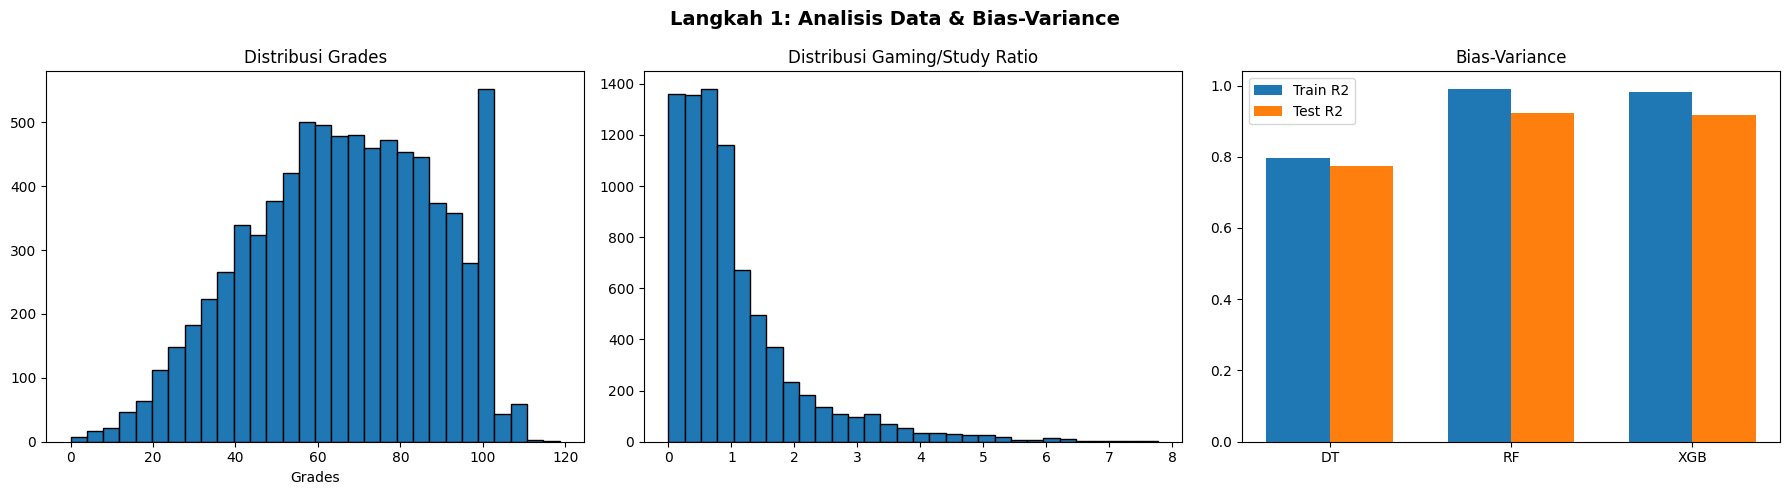


[OUTPUT] Grafik tersimpan: langkah1_analisis.png


In [ ]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------------
path = kagglehub.dataset_download("aiexplorer77/gaming-vs-academic-performance")

print("=" * 60)
print("=== ANALISIS KARAKTERISTIK DATA & ERROR ===")
print("=" * 60)

df = pd.read_csv(os.path.join(path, "Gaming_Academic_Performance.csv"))

print(f"Total data: {df.shape[0]} baris, {df.shape[1]} kolom")

# ---------------------------------------------------------------
# FEATURE ENGINEERING
# ---------------------------------------------------------------
print("Membuat fitur gaming_study_ratio...")

df["gaming_study_ratio"] = df["gaming_hours"] / df["study_hours"].replace(0, 1)

# ---------------------------------------------------------------
# CLEANING
# ---------------------------------------------------------------
df = df.dropna()
print(f"Setelah cleaning: {df.shape[0]} baris")

# ---------------------------------------------------------------
# ENCODING
# ---------------------------------------------------------------
print("Encoding semua kolom kategorikal...")

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# ---------------------------------------------------------------
# PILIH FITUR & TARGET
# ---------------------------------------------------------------
FITUR = [
    "gaming_hours",
    "study_hours",
    "gaming_study_ratio",
    "sleep_hours",
    "attendance",
    "addiction_score",
    "stress_level"
]

TARGET = "grades"

X = df[FITUR]
y = df[TARGET]

# ---------------------------------------------------------------
# SPLIT DATA
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nData Training : {X_train.shape[0]} sampel")
print(f"Data Testing  : {X_test.shape[0]} sampel")

# ---------------------------------------------------------------
# ANALISIS DATA
# ---------------------------------------------------------------
print("\n=== INFORMASI DATA ===")
print(X.describe())

print("\n=== DISTRIBUSI TARGET (GRADES) ===")
print(y.describe())

# ---------------------------------------------------------------
# ANALISIS BIAS & VARIANCE
# ---------------------------------------------------------------
print("\n=== ANALISIS BIAS & VARIANCE ===")

models_cek = {
    'Decision Tree (Weak)': DecisionTreeRegressor(max_depth=3, random_state=42),
    'Random Forest (Bagging)': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost (Boosting)': xgb.XGBRegressor(n_estimators=100, random_state=42)
}

hasil_bv = []

for nama, model in models_cek.items():
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score  = model.score(X_test, y_test)

    hasil_bv.append({
        "Model": nama,
        "Train_R2": round(train_score, 4),
        "Test_R2": round(test_score, 4),
        "Gap": round(train_score - test_score, 4)
    })

df_bv = pd.DataFrame(hasil_bv)
print(df_bv.to_string(index=False))

# ---------------------------------------------------------------
# INTERPRETASI OTOMATIS
# ---------------------------------------------------------------
print("\n[INTERPRETASI LANGKAH 1]:")

for _, row in df_bv.iterrows():
    if row["Gap"] > 0.1:
        print(f"  - {row['Model']}: Gap besar ({row['Gap']}) → High Variance → Cocok pakai BAGGING")
    elif row["Train_R2"] < 0.6:
        print(f"  - {row['Model']}: Train rendah → High Bias → Cocok pakai BOOSTING")
    else:
        print(f"  - {row['Model']}: Stabil → Model cukup baik")

# ---------------------------------------------------------------
# VISUALISASI
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle('Langkah 1: Analisis Data & Bias-Variance', fontsize=14, fontweight='bold')

# 1. Distribusi target
axes[0].hist(y, bins=30, edgecolor='black')
axes[0].set_title('Distribusi Grades')
axes[0].set_xlabel('Grades')

# 2. Distribusi ratio
axes[1].hist(df["gaming_study_ratio"], bins=30, edgecolor='black')
axes[1].set_title('Distribusi Gaming/Study Ratio')

# 3. Bias vs Variance
x_idx = np.arange(len(df_bv))
w = 0.35

axes[2].bar(x_idx - w/2, df_bv["Train_R2"], w, label="Train R2")
axes[2].bar(x_idx + w/2, df_bv["Test_R2"],  w, label="Test R2")

axes[2].set_xticks(x_idx)
axes[2].set_xticklabels(["DT", "RF", "XGB"])
axes[2].set_title("Bias-Variance")
axes[2].legend()

plt.tight_layout()
plt.savefig("langkah1_analisis.png", dpi=150)
plt.show()

print("\n[OUTPUT] Grafik tersimpan: langkah1_analisis.png")

# DESAIN ARSITEKTUR MODEL ENSEMBLE


=== DESAIN ARSITEKTUR MODEL ENSEMBLE (REGRESI) ===

[2A] BAGGING — Random Forest:
     R² Random Forest  : 0.9234

[2B] BOOSTING — XGBoost:
     R² XGBoost        : 0.9274

[2C] STACKING — Meta-Learner (RF + XGB):
     R² Stacking       : 0.9254

=== RINGKASAN ARSITEKTUR LANGKAH 2 ===
Arsitektur                     Metode               R²
-------------------------------------------------------
Random Forest (Bagging)        Paralel              0.9234
XGBoost (Boosting)             Sequential           0.9274
Stacking (RF+XGB)              Meta-Learner         0.9254


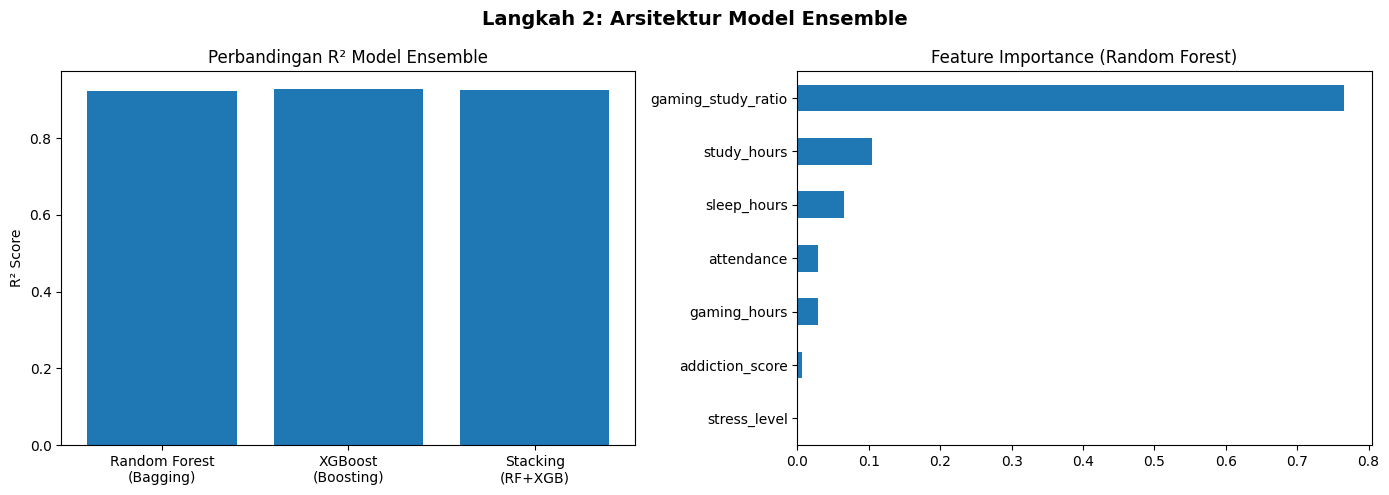

[OUTPUT] Grafik tersimpan: langkah2_arsitektur.png


In [ ]:
print("\n" + "=" * 60)
print("=== DESAIN ARSITEKTUR MODEL ENSEMBLE (REGRESI) ===")
print("=" * 60)

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ===============================================================
# [2A] BAGGING — RANDOM FOREST
# ===============================================================
print("\n[2A] BAGGING — Random Forest:")

model_bagging = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model_bagging.fit(X_train, y_train)
y_pred_rf = model_bagging.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"     R² Random Forest  : {r2_rf:.4f}")

# ===============================================================
# [2B] BOOSTING — XGBOOST
# ===============================================================
print("\n[2B] BOOSTING — XGBoost:")

model_boosting = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

model_boosting.fit(X_train, y_train)
y_pred_xgb = model_boosting.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"     R² XGBoost        : {r2_xgb:.4f}")

# ===============================================================
# [2C] STACKING — RF + XGB
# ===============================================================
print("\n[2C] STACKING — Meta-Learner (RF + XGB):")

estimators = [
    ('rf', RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42)),
    ('xgb', xgb.XGBRegressor(n_estimators=50, max_depth=4, random_state=42))
]

model_stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=3,
    n_jobs=-1
)

model_stacking.fit(X_train, y_train)
y_pred_stk = model_stacking.predict(X_test)
r2_stk = r2_score(y_test, y_pred_stk)

print(f"     R² Stacking       : {r2_stk:.4f}")

# ===============================================================
# RINGKASAN
# ===============================================================
print("\n=== RINGKASAN ARSITEKTUR LANGKAH 2 ===")
print(f"{'Arsitektur':<30} {'Metode':<20} {'R²'}")
print("-" * 55)
print(f"{'Random Forest (Bagging)':<30} {'Paralel':<20} {r2_rf:.4f}")
print(f"{'XGBoost (Boosting)':<30} {'Sequential':<20} {r2_xgb:.4f}")
print(f"{'Stacking (RF+XGB)':<30} {'Meta-Learner':<20} {r2_stk:.4f}")

# ===============================================================
# VISUALISASI
# ===============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Langkah 2: Arsitektur Model Ensemble', fontsize=14, fontweight='bold')

arsitektur = ['Random Forest\n(Bagging)', 'XGBoost\n(Boosting)', 'Stacking\n(RF+XGB)']
r2_scores = [r2_rf, r2_xgb, r2_stk]

axes[0].bar(arsitektur, r2_scores)
axes[0].set_title('Perbandingan R² Model Ensemble')
axes[0].set_ylabel('R² Score')

# Feature Importance (RF)
import pandas as pd
imp_rf = pd.Series(model_bagging.feature_importances_, index=FITUR).sort_values()
imp_rf.plot(kind='barh', ax=axes[1])
axes[1].set_title('Feature Importance (Random Forest)')

plt.tight_layout()
plt.savefig('langkah2_arsitektur.png', dpi=150)
plt.show()

print("[OUTPUT] Grafik tersimpan: langkah2_arsitektur.png")

# TRAINING DAN TUNING HYPERPARAMETER

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# 1. Tuning Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)

# Menampilkan Hasil RF
print("Best RF params:", grid_rf.best_params_)
print(f"RF Best CV R2 : {grid_rf.best_score_:.4f}")
print(f"RF Train R2   : {grid_rf.best_estimator_.score(X_train, y_train):.4f}")
print(f"RF Test R2    : {grid_rf.best_estimator_.score(X_test, y_test):.4f}")
print("-" * 30)

# 2. Tuning XGBoost
param_dist_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
rand_xgb = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_dist_xgb, n_iter=30, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
rand_xgb.fit(X_train, y_train)

# Menampilkan Hasil XGBoost
print("Best XGB params:", rand_xgb.best_params_)
print(f"XGB Best CV R2: {rand_xgb.best_score_:.4f}")
print(f"XGB Train R2  : {rand_xgb.best_estimator_.score(X_train, y_train):.4f}")
print(f"XGB Test R2   : {rand_xgb.best_estimator_.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
RF Best CV R2 : 0.9321
RF Train R2   : 0.9778
RF Test R2    : 0.9242
------------------------------
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
XGB Best CV R2: 0.9363
XGB Train R2  : 0.9589
XGB Test R2   : 0.9280


# VALIDASI KETAT DENGAN K-FOLD

------------------------------------------------------------
--- LANGKAH 4: VALIDASI KETAT DENGAN K-FOLD (TUNED MODELS) ---
------------------------------------------------------------
Menjalankan K-Fold (5-Fold)...

Model: Tuned Random Forest
  Skor R2 per fold : [0.9237 0.931  0.9366 0.9339 0.9302]
  Rata-rata R2     : 0.9311
  Standar Deviasi  : 0.0043
  Interpretasi     : Model sangat stabil lintas data (Variance rendah) ✅

Model: Tuned XGBoost
  Skor R2 per fold : [0.928  0.9348 0.9402 0.936  0.9342]
  Rata-rata R2     : 0.9346
  Standar Deviasi  : 0.0039
  Interpretasi     : Model sangat stabil lintas data (Variance rendah) ✅



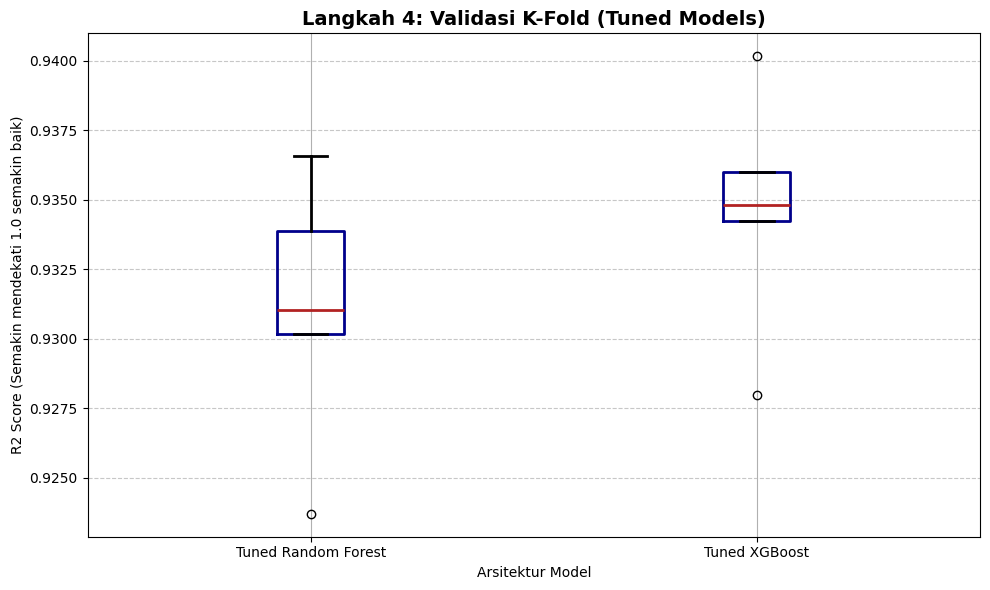


[OUTPUT] Grafik tersimpan: langkah4_kfold_validasi_tuned.png


In [ ]:
print("-" * 60)
print("--- LANGKAH 4: VALIDASI KETAT DENGAN K-FOLD (TUNED MODELS) ---")
print("-" * 60)

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Setup K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Ambil model TERBAIK dari Langkah 3
# Kita ambil best_estimator_ dari hasil pencarian tuning
tuned_rf = grid_rf.best_estimator_
tuned_xgb = rand_xgb.best_estimator_


# Masukkan ke dictionary K-Fold
models_kfold = {
    'Tuned Random Forest': tuned_rf,
    'Tuned XGBoost': tuned_xgb,
}

# Menyimpan hasil untuk divisualisasikan
cv_results = {}

print("Menjalankan K-Fold (5-Fold)...\n")

# 3. Evaluasi setiap model
for name, model in models_kfold.items():
    # Menggunakan R2 score sebagai metrik evaluasi regresi
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = scores

    mean_score = scores.mean()
    std_score = scores.std()

    print(f"Model: {name}")
    print(f"  Skor R2 per fold : {np.round(scores, 4)}")
    print(f"  Rata-rata R2     : {mean_score:.4f}")
    print(f"  Standar Deviasi  : {std_score:.4f}")

    # Interpretasi otomatis sederhana
    if std_score < 0.05:
        print("  Interpretasi     : Model sangat stabil lintas data (Variance rendah) ✅\n")
    elif std_score < 0.10:
        print("  Interpretasi     : Model cukup stabil, ada sedikit fluktuasi ⚠️\n")
    else:
        print("  Interpretasi     : Model kurang stabil (Indikasi Overfitting pada fold tertentu) ❌\n")

# 4. Visualisasi Distribusi K-Fold (Boxplot)
fig, ax = plt.subplots(figsize=(10, 6))

df_cv = pd.DataFrame(cv_results)

# Membuat Boxplot dengan styling bersih
medianprops = dict(linestyle='-', linewidth=2, color='firebrick')
boxprops = dict(linestyle='-', linewidth=2, color='darkblue')

df_cv.boxplot(ax=ax, boxprops=boxprops, medianprops=medianprops,
              whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2))

ax.set_title('Langkah 4: Validasi K-Fold (Tuned Models)', fontsize=14, fontweight='bold')
ax.set_ylabel('R2 Score (Semakin mendekati 1.0 semakin baik)')
ax.set_xlabel('Arsitektur Model')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('langkah4_kfold_validasi_tuned.png', dpi=150)
plt.show()

print("\n[OUTPUT] Grafik tersimpan: langkah4_kfold_validasi_tuned.png")

# INTERPRETASI MODEL MENGGUNAKAN XAI (SHAP VALUES)


=== INTERPRETASI MODEL (EXPLAINABLE AI) ===
Menghitung SHAP values dari model XGBoost hasil tuning...


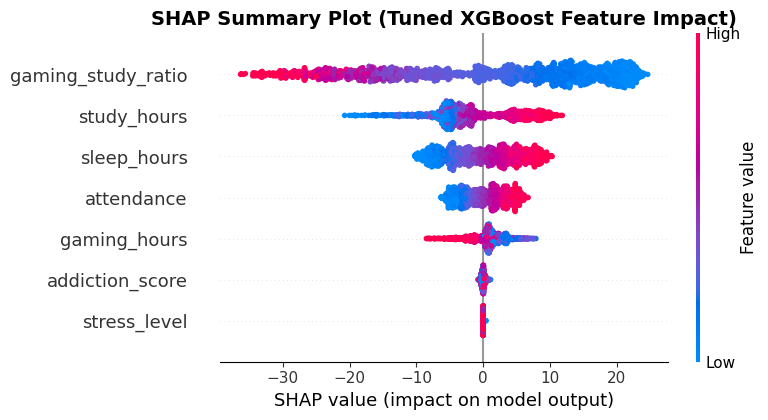


[OUTPUT] Grafik XAI tersimpan: langkah5_interpretasi_xai.png

[KETERANGAN GRAFIK INTERPRETASI MODEL]:
Berdasarkan grafik SHAP Summary Plot dari model XGBoost yang telah di-tuning, kita dapat menginterpretasikan dampaknya sebagai berikut:
1. Fitur paling berpengaruh: 'gaming_study_ratio' memiliki dampak paling besar terhadap hasil prediksi grades.
2. Urutan prioritas: Fitur terpenting kedua dan ketiga berturut-turut adalah 'study_hours' dan 'sleep_hours'.
3. Cara membaca warna (Nilai Fitur): Titik merah merepresentasikan nilai fitur yang tinggi, sedangkan titik biru merepresentasikan nilai fitur yang rendah.
4. Cara membaca posisi (Dampak):
   - Titik yang menumpuk di sebelah KANAN garis vertikal (SHAP value > 0) menunjukkan bahwa nilai fitur tersebut cenderung MENINGKATKAN prediksi grades.
   - Titik yang menumpuk di sebelah KIRI garis vertikal (SHAP value < 0) menunjukkan kecenderungan MENURUNKAN prediksi grades.
   - Sebaran titik yang melebar menandakan fitur tersebut memiliki rent

In [ ]:
# ===============================================================
# INTERPRETASI MODEL DENGAN XAI (SHAP) - REVISI TUNING
# ===============================================================
print("\n" + "=" * 60)
print("=== INTERPRETASI MODEL (EXPLAINABLE AI) ===")
print("=" * 60)

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Inisialisasi SHAP Explainer
# MENGGUNAKAN MODEL BARU: Kita ekstrak model XGBoost terbaik hasil tuning
# menggunakan rand_xgb.best_estimator_
best_xgb_model = rand_xgb.best_estimator_

print("Menghitung SHAP values dari model XGBoost hasil tuning...")
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test)

# 2. Visualisasi SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot (Tuned XGBoost Feature Impact)", fontsize=14, fontweight='bold')
# show=False agar kita bisa menyimpan gambarnya dulu sebelum ditampilkan
shap.summary_plot(shap_values, X_test, feature_names=FITUR, show=False)

plt.tight_layout()
plt.savefig('langkah5_interpretasi_xai.png', dpi=150)
plt.show()

print("\n[OUTPUT] Grafik XAI tersimpan: langkah5_interpretasi_xai.png")

# 3. Ekstrak urutan Feature Importance dari SHAP untuk teks penjelasan
# Menghitung rata-rata nilai absolut SHAP untuk setiap fitur
mean_shap_values = np.abs(shap_values).mean(axis=0)
df_shap_imp = pd.DataFrame(list(zip(FITUR, mean_shap_values)), columns=['Fitur', 'Dampak Rata-rata'])
df_shap_imp.sort_values(by=['Dampak Rata-rata'], ascending=False, inplace=True)

# Mengambil 3 fitur teratas
top_1 = df_shap_imp.iloc[0]['Fitur']
top_2 = df_shap_imp.iloc[1]['Fitur']
top_3 = df_shap_imp.iloc[2]['Fitur']

# 4. Mencetak Keterangan Teks Otomatis
print("\n[KETERANGAN GRAFIK INTERPRETASI MODEL]:")
print(f"Berdasarkan grafik SHAP Summary Plot dari model XGBoost yang telah di-tuning, kita dapat menginterpretasikan dampaknya sebagai berikut:")
print(f"1. Fitur paling berpengaruh: '{top_1}' memiliki dampak paling besar terhadap hasil prediksi grades.")
print(f"2. Urutan prioritas: Fitur terpenting kedua dan ketiga berturut-turut adalah '{top_2}' dan '{top_3}'.")
print(f"3. Cara membaca warna (Nilai Fitur): Titik merah merepresentasikan nilai fitur yang tinggi, sedangkan titik biru merepresentasikan nilai fitur yang rendah.")
print(f"4. Cara membaca posisi (Dampak):")
print(f"   - Titik yang menumpuk di sebelah KANAN garis vertikal (SHAP value > 0) menunjukkan bahwa nilai fitur tersebut cenderung MENINGKATKAN prediksi grades.")
print(f"   - Titik yang menumpuk di sebelah KIRI garis vertikal (SHAP value < 0) menunjukkan kecenderungan MENURUNKAN prediksi grades.")
print("   - Sebaran titik yang melebar menandakan fitur tersebut memiliki rentang dampak yang bervariasi bergantung pada kombinasi kondisi siswa lainnya.")